## IMPORT LIBRARIES

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving low_popularity_spotify_data.csv to low_popularity_spotify_data.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##CLEAN AND CLASSIFY DATA

In [ ]:
high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

In [ ]:
df = pd.concat([high, low], ignore_index=True)


In [ ]:
df_clean = df.drop_duplicates(subset=["track_id"]).copy()

In [ ]:
df = df_clean.dropna()

In [ ]:
X = df.drop(columns = ["track_popularity"])
y= df["track_popularity"]

In [ ]:
numeric_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "speechiness",
    "instrumentalness",
    "acousticness",
    "duration_ms",
    "mode",
    "key"
]

categorical_features = [
    "playlist_genre",
    "playlist_subgenre"
]

##BUILDING A BASELINE MODEL (NO FEATURE ENGINEERING YET) USING GRADIENT BOOSTING REGRESSOR
-NO ARTIST FEATURES YET (artist_following, artist_popularity, artist_influence)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['playlist_genre',
                                                   'playlist_subgenre']),
                                                 ('num', 'passthrough',
                                                  ['danceability', 'energy',
                                                   'valence', 'tempo',
                                                   'loudness', 'speechiness',
                                                   'instrumentalness',
                                                   'acousticness',
                                                   'duration_ms', 'mode',
                                                   'key'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 10.281824074953764
RMSE: 13.151183125195125
R²: 0.55687256056894


## BUILDING XGBoost MODEL WITH ARTIST FEATURES INCLUDED IN THE DATASET

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving spotify_enriched_5k.csv to spotify_enriched_5k.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("spotify_enriched_5k.csv")

y = df["track_popularity"]

cols_to_drop = [
    "track_popularity", "track_id", "track_name", "track_artist",
    "track_album_id", "track_album_name", "track_href", "uri",
    "analysis_url", "id", "track_album_release_date", "type",
    "playlist_id", "playlist_name", "primary_artist", "artist_name_clean"
]

X = df.drop(columns=cols_to_drop, errors='ignore')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "danceability", "energy", "valence", "tempo", "loudness",
    "speechiness", "instrumentalness", "acousticness",
    "duration_ms", "mode", "key", "time_signature", "liveness",
    "artist_popularity", "artist_followers", "has_artist_metadata"
]

categorical_features = [
    "playlist_genre",
    "playlist_subgenre"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_val)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Validation MAE:  8.2436
Validation RMSE: 11.0704
Validation R²:   0.6764


good improvement!

## APPLY SOME FEATURE ENGINEERING
- utilize the release date of the tracks based on how old they are
- create artist influence through log transformation of followers combined with popularity
- try energy and danceability combination

In [ ]:
df = pd.read_csv("spotify_enriched_5k.csv")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')

df['release_year'] = df['track_album_release_date'].dt.year
df['release_month'] = df['track_album_release_date'].dt.month

reference_date = pd.to_datetime('today')
df['song_age_days'] = (reference_date - df['track_album_release_date']).dt.days


df['artist_influence'] = df['artist_popularity'] * np.log1p(df['artist_followers'])


df['energy_danceability'] = df['energy'] * df['danceability']

y = df["track_popularity"]

cols_to_drop = [
    "track_popularity", "track_id", "track_name", "track_artist",
    "track_album_id", "track_album_name", "track_href", "uri",
    "analysis_url", "id", "track_album_release_date", "type",
    "playlist_id", "playlist_name", "primary_artist", "artist_name_clean"
]

X = df.drop(columns=cols_to_drop, errors='ignore')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
numeric_features = [
    "danceability", "energy", "valence", "tempo", "loudness",
    "speechiness", "instrumentalness", "acousticness",
    "duration_ms", "mode", "key", "time_signature", "liveness",
    "artist_popularity", "artist_followers", "has_artist_metadata",
    "song_age_days", "release_year", "release_month",
    "artist_influence", "energy_danceability"
]



## REDO MODEL TRAINING

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])


pipeline.fit(X_train, y_train)


preds = pipeline.predict(X_val)


mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print(f"Validation MAE:  {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²:   {r2:.4f}")

Validation MAE:  8.0105
Validation RMSE: 10.7929
Validation R²:   0.6925


improving again!

##APPLY HYPERPARAMETER TUNING TO PUSH FOR 0.70!

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.15],
    'model__n_estimators': [200, 400, 600, 800],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7]
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=25,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


print("Starting hyperparameter tuning..")
random_search.fit(X_train, y_train)

Starting hyperparameter tuning... this is a great time to grab a coffee! ☕
Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['playlist_genre',
                                                                                'playlist_subgenre']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['danceability',
                                                                                'energy',
                                                                                'valence',
                                                                                'tempo',
                                                                                'loudness',
                                                                                'speechiness',
                                                                                'instrumentalness',
                                                                                'acousticness',
                                                                                'duration_ms',
                                                                                'mode',
                                                                                'key',
                                                                                'time_signature'...
                                                           n_estimators=300,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.15],
                                        'model__max_depth': [3, 4, 5, 6, 8],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [200, 400, 600,
                                                                800],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

-EXTRACT BEST MODEL

-MAKE PREDICTIONS USING BEST MODEL

-EVALUATION OF BEST MODEL

In [ ]:

best_pipeline = random_search.best_estimator_


best_preds = best_pipeline.predict(X_val)


best_mae = mean_absolute_error(y_val, best_preds)
best_rmse = np.sqrt(mean_squared_error(y_val, best_preds))
best_r2 = r2_score(y_val, best_preds)

print("\n=== FINAL TUNING RESULTS ===")
print(f"Validation MAE:  {best_mae:.4f}")
print(f"Validation RMSE: {best_rmse:.4f}")
print(f"Validation R²:   {best_r2:.4f}")
print("\nChampion Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f" - {param.replace('model__', '')}: {value}")


=== FINAL TUNING RESULTS ===
Validation MAE:  7.5254
Validation RMSE: 10.3586
Validation R²:   0.7167

Champion Parameters Found:
 - subsample: 1.0
 - n_estimators: 600
 - min_child_weight: 3
 - max_depth: 6
 - learning_rate: 0.05
 - colsample_bytree: 1.0


best model so far!

## VISUALIZING FEATURE IMPORTANCE & TRACK POPULARITY DISTRIBUTION
- visualize the most important features which were the greatest determining factors.
- aiming to analyze the track popularity distribution to see if there are bottlenecks within it and if I can further tweak it to improve the model.

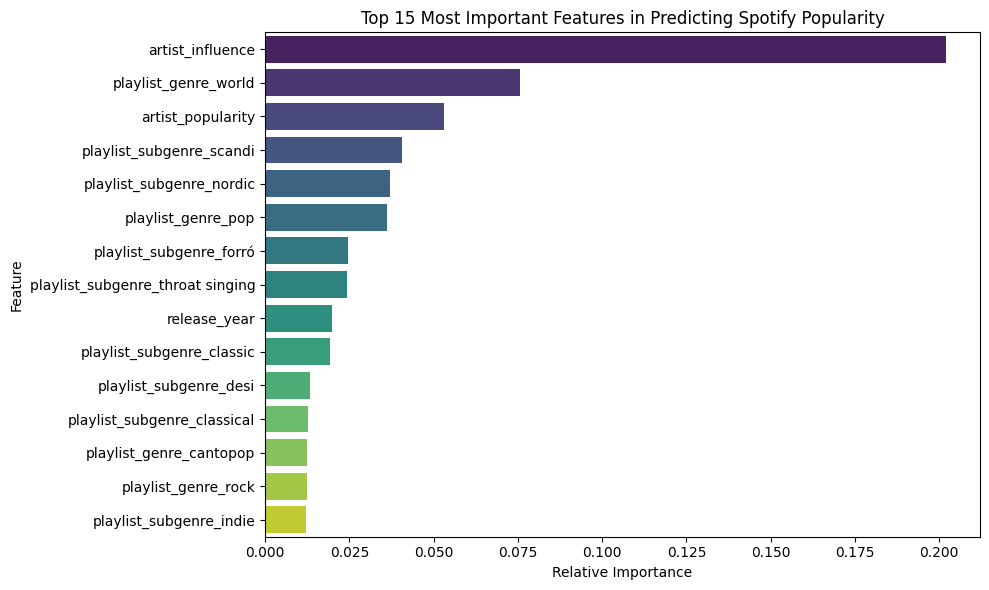

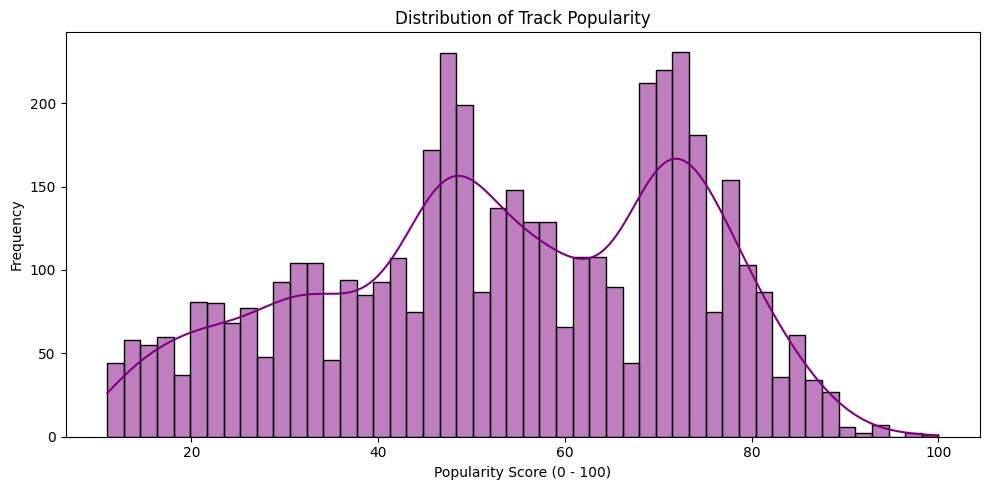

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


champion_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']


feature_names = preprocessor.get_feature_names_out()


clean_feature_names = [name.split('__')[-1] for name in feature_names]


importances = champion_model.feature_importances_


importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Top 15 Most Important Features in Predicting Spotify Popularity")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()




plt.figure(figsize=(10, 5))
sns.histplot(y, bins=50, kde=True, color='purple')
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity Score (0 - 100)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

ANALYSIS OF THE LEFT AND RIGHT PEAKS OF THE DISTRIBUTION

In [ ]:
import pandas as pd
import numpy as np


analysis_df = df.copy()


analysis_df['peak_group'] = np.where(
    analysis_df['track_popularity'] <= 60,
    'Left Peak (<=60)',
    'Right Peak (>60)'
)


features_to_compare = [
    'track_popularity',
    'artist_influence',
    'artist_popularity',
    'has_artist_metadata',
    'release_year',
    'song_age_days',
    'energy',
    'danceability'
]

numeric_comparison = analysis_df.groupby('peak_group')[features_to_compare].mean().T

print("=== NUMERIC FEATURE COMPARISON (AVERAGES) ===")
print(numeric_comparison.round(2))


print("\n=== TOP GENRES: LEFT PEAK (<=60) ===")
print(analysis_df[analysis_df['peak_group'] == 'Left Peak (<=60)']['playlist_genre'].value_counts(normalize=True).head(3).round(3) * 100)

print("\n=== TOP GENRES: RIGHT PEAK (>60) ===")
print(analysis_df[analysis_df['peak_group'] == 'Right Peak (>60)']['playlist_genre'].value_counts(normalize=True).head(3).round(3) * 100)

=== NUMERIC FEATURE COMPARISON (AVERAGES) ===
peak_group           Left Peak (<=60)  Right Peak (>60)
track_popularity                40.25             73.01
artist_influence              1027.43           1280.84
artist_popularity               68.80             78.72
has_artist_metadata              0.07              0.61
release_year                  2019.78           2013.93
song_age_days                 2266.81           4407.82
energy                           0.53              0.65
danceability                     0.60              0.65

=== TOP GENRES: LEFT PEAK (<=60) ===
playlist_genre
electronic    13.7
lofi          10.9
ambient        8.8
Name: proportion, dtype: float64

=== TOP GENRES: RIGHT PEAK (>60) ===
playlist_genre
pop        17.2
hip-hop    14.1
rock       12.8
Name: proportion, dtype: float64


ADDING MAINSTREAM AND NICHE GENRES CLASSIFICATION SO THAT THE MODEL WILL NOT BE CONFUSED WITH THE VALLEY

In [ ]:
mainstream_genres = ['pop', 'hip-hop', 'rock']
niche_genres = ['electronic', 'lofi', 'ambient']


df['is_mainstream_genre'] = df['playlist_genre'].isin(mainstream_genres).astype(int)
df['is_niche_genre'] = df['playlist_genre'].isin(niche_genres).astype(int)

df['mainstream_metadata_combo'] = df['is_mainstream_genre'] * df['has_artist_metadata']


y = df["track_popularity"]

cols_to_drop = [
    "track_popularity", "track_id", "track_name", "track_artist",
    "track_album_id", "track_album_name", "track_href", "uri",
    "analysis_url", "id", "track_album_release_date", "type",
    "playlist_id", "playlist_name", "primary_artist", "artist_name_clean"
]
X = df.drop(columns=cols_to_drop, errors='ignore')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


numeric_features = [
    "danceability", "energy", "valence", "tempo", "loudness",
    "speechiness", "instrumentalness", "acousticness",
    "duration_ms", "mode", "key", "time_signature", "liveness",
    "artist_popularity", "artist_followers", "has_artist_metadata",
    "song_age_days", "release_year", "release_month",
    "artist_influence", "energy_danceability",
    "is_mainstream_genre", "is_niche_genre", "mainstream_metadata_combo"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["playlist_genre", "playlist_subgenre"]),
        ("num", "passthrough", numeric_features)
    ]
)


from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

champion_xgb = XGBRegressor(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=600,
    subsample=1.0,
    colsample_bytree=1.0,
    min_child_weight=3,
    random_state=42
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', champion_xgb)
])

print("Training the final optimized model...")
final_pipeline.fit(X_train, y_train)

final_preds = final_pipeline.predict(X_val)

final_mae = mean_absolute_error(y_val, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_val, final_preds))
final_r2 = r2_score(y_val, final_preds)

print("\n=== THE ULTIMATE MODEL RESULTS ===")
print(f"Validation MAE:  {final_mae:.4f}")
print(f"Validation RMSE: {final_rmse:.4f}")
print(f"Validation R²:   {final_r2:.4f}")

Training the final optimized model...

=== THE ULTIMATE MODEL RESULTS ===
Validation MAE:  7.5042
Validation RMSE: 10.3063
Validation R²:   0.7196


- the model improved a little bit with the genres classification but not much. the dataset might be reaching its ceiling.

# SHAP APPLICATION
-

In [ ]:
!pip install shap

Calculating SHAP values... this usually takes just a few seconds for XGBoost!


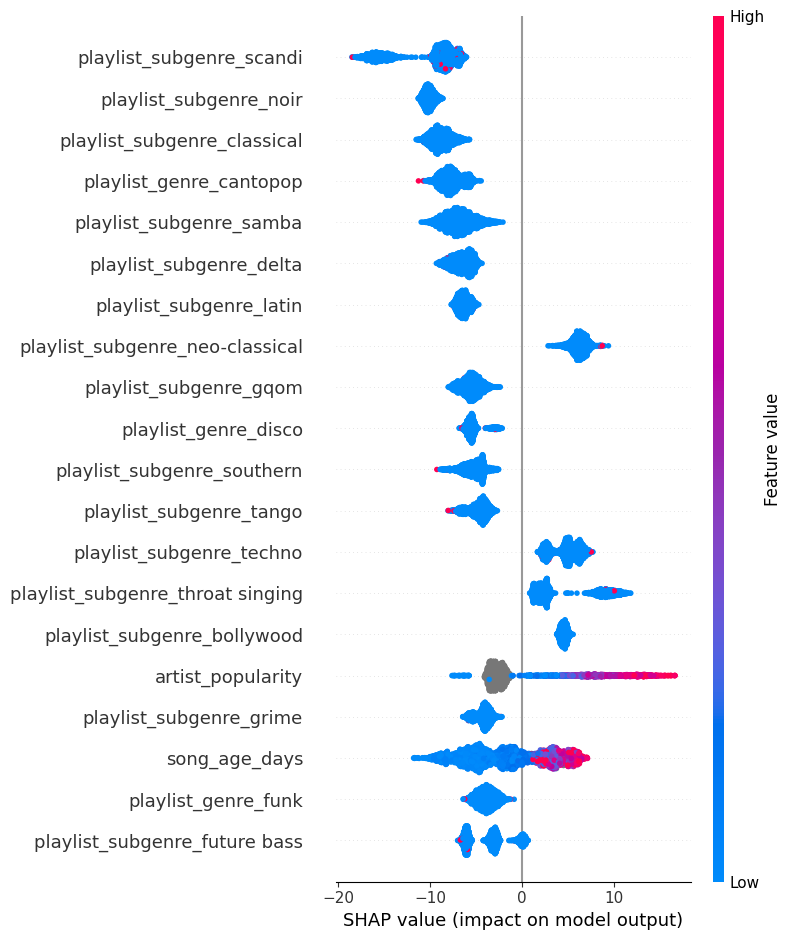

In [ ]:
import shap
import pandas as pd

preprocessor = final_pipeline.named_steps['preprocessor']
champion_xgb = final_pipeline.named_steps['model']

X_train_transformed = preprocessor.transform(X_train)

if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in feature_names]

X_train_shap = pd.DataFrame(X_train_transformed, columns=clean_feature_names)

print("Calculating SHAP values... this usually takes just a few seconds for XGBoost!")
explainer = shap.TreeExplainer(champion_xgb)
shap_values = explainer.shap_values(X_train_shap)

shap.summary_plot(shap_values, X_train_shap)